In [1]:
!pip -q install numpy pandas scipy scikit-learn networkx matplotlib

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from typing import Dict, Iterable, List, Sequence, Set, Tuple

import networkx as nx
import numpy as np
import pandas as pd
import scipy.linalg as slin
from scipy.optimize import minimize
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [3]:
@dataclass(frozen=True)
class EdgePrior:
    source: str
    target: str
    weight: float
    kind: str = "soft"  # required | forbidden | soft


def matrix_to_digraph(W: np.ndarray, variables: Sequence[str], threshold: float = 0.0) -> nx.DiGraph:
    g = nx.DiGraph()
    g.add_nodes_from(variables)
    d = len(variables)
    for i in range(d):
        for j in range(d):
            if i == j:
                continue
            if abs(W[i, j]) > threshold:
                g.add_edge(variables[i], variables[j], weight=float(W[i, j]))
    return g


def threshold_to_dag(W: np.ndarray, variables: Sequence[str], threshold: float) -> nx.DiGraph:
    g = matrix_to_digraph(W, variables, threshold=threshold)
    if nx.is_directed_acyclic_graph(g):
        return g
    # remove weakest edges until acyclic
    edges = sorted(g.edges(data=True), key=lambda x: abs(float(x[2].get("weight", 0.0))))
    for u, v, _ in edges:
        if nx.is_directed_acyclic_graph(g):
            break
        g.remove_edge(u, v)
    return g


def precision_recall_f1(pred: nx.DiGraph, truth: nx.DiGraph) -> Dict[str, float]:
    p = set(pred.edges())
    t = set(truth.edges())
    tp = len(p & t)
    fp = len(p - t)
    fn = len(t - p)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    shd = len((p - t) | (t - p))
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "pred_edges": len(p),
        "true_edges": len(t),
        "shd": shd,
    }


def build_prior_matrices(variables: Sequence[str], priors: Iterable[EdgePrior]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    idx = {v: i for i, v in enumerate(variables)}
    d = len(variables)
    weights = np.zeros((d, d))
    required = np.zeros((d, d), dtype=bool)
    forbidden = np.zeros((d, d), dtype=bool)
    for p in priors:
        i, j = idx[p.source], idx[p.target]
        weights[i, j] = p.weight
        if p.kind == "required":
            required[i, j] = True
        elif p.kind == "forbidden":
            forbidden[i, j] = True
    np.fill_diagonal(weights, 0.0)
    return weights, required, forbidden


def merge_priors(*prior_sets: Iterable[EdgePrior]) -> List[EdgePrior]:
    merged: Dict[Tuple[str, str], EdgePrior] = {}
    for prior_set in prior_sets:
        for p in prior_set:
            key = (p.source, p.target)
            current = merged.get(key)
            if current is None or abs(p.weight) > abs(current.weight):
                merged[key] = p
    return list(merged.values())

In [4]:
VARIABLES = [
    "Market_Return",
    "Interest_Rate",
    "Regulatory_Risk",
    "Inflation",
    "Competition_Intensity",
    "Governance_Score",
    "ESG_Score",
    "Innovation_Index",
    "Revenue_Growth",
    "Cost_Efficiency",
    "EBITDA_Margin",
    "Leverage",
    "Liquidity",
    "Credit_Risk",
    "Valuation_Multiple",
    "Earnings_Surprise",
    "Sentiment",
    "Monthly_Return",
]

TRUE_EDGES = [
    ("Inflation", "Interest_Rate"),
    ("Inflation", "Market_Return"),
    ("Regulatory_Risk", "Sentiment"),
    ("Regulatory_Risk", "Revenue_Growth"),
    ("Regulatory_Risk", "EBITDA_Margin"),
    ("Competition_Intensity", "Revenue_Growth"),
    ("Competition_Intensity", "EBITDA_Margin"),
    ("Governance_Score", "Leverage"),
    ("Governance_Score", "Liquidity"),
    ("Governance_Score", "Credit_Risk"),
    ("ESG_Score", "Sentiment"),
    ("ESG_Score", "Valuation_Multiple"),
    ("Innovation_Index", "Revenue_Growth"),
    ("Innovation_Index", "Valuation_Multiple"),
    ("Revenue_Growth", "EBITDA_Margin"),
    ("Revenue_Growth", "Valuation_Multiple"),
    ("Revenue_Growth", "Monthly_Return"),
    ("Cost_Efficiency", "EBITDA_Margin"),
    ("Cost_Efficiency", "Monthly_Return"),
    ("EBITDA_Margin", "Valuation_Multiple"),
    ("EBITDA_Margin", "Monthly_Return"),
    ("Leverage", "Credit_Risk"),
    ("Leverage", "Valuation_Multiple"),
    ("Liquidity", "Credit_Risk"),
    ("Credit_Risk", "Valuation_Multiple"),
    ("Credit_Risk", "Monthly_Return"),
    ("Market_Return", "Monthly_Return"),
    ("Earnings_Surprise", "Sentiment"),
    ("Sentiment", "Monthly_Return"),
]

In [5]:


@dataclass
class SyntheticDataset:
    data: pd.DataFrame
    truth_graph: nx.DiGraph
    kg_priors: List[EdgePrior]
    llm_priors: List[EdgePrior]


def _zscore(df: pd.DataFrame) -> pd.DataFrame:
    return (df - df.mean()) / df.std(ddof=0)


def build_truth_graph() -> nx.DiGraph:
    g = nx.DiGraph()
    g.add_nodes_from(VARIABLES)
    g.add_edges_from(TRUE_EDGES)
    return g


def generate_synthetic_finance_data(n_firms: int = 500, n_periods: int = 60, seed: int = 7) -> SyntheticDataset:
    rng = np.random.default_rng(seed)
    rows: List[Dict[str, float]] = []

    firm_quality = rng.normal(0, 1, size=n_firms)
    firm_risk = rng.normal(0, 1, size=n_firms)
    firm_innovation = rng.normal(0, 1, size=n_firms)

    for t in range(n_periods):
        inflation_t = 0.4 * np.sin(t / 8.0) + rng.normal(0, 0.5)
        rate_t = 0.7 * inflation_t + rng.normal(0, 0.35)
        market_t = -0.25 * inflation_t + rng.normal(0, 0.7)
        reg_t = 0.35 * np.cos(t / 10.0) + rng.normal(0, 0.45)
        comp_t = 0.2 * np.sin(t / 6.0) + rng.normal(0, 0.4)

        for i in range(n_firms):
            governance = 0.8 * firm_quality[i] - 0.2 * firm_risk[i] + rng.normal(0, 0.4)
            esg = 0.5 * governance + 0.25 * firm_quality[i] + rng.normal(0, 0.4)
            innovation = 0.8 * firm_innovation[i] + 0.2 * governance + rng.normal(0, 0.5)
            cost_eff = 0.5 * governance + 0.2 * innovation + rng.normal(0, 0.5)
            revenue = (
                0.35 * innovation
                - 0.30 * reg_t
                - 0.28 * comp_t
                + 0.15 * market_t
                + rng.normal(0, 0.6)
            )
            ebitda = (
                0.42 * revenue
                + 0.35 * cost_eff
                - 0.22 * comp_t
                + 0.18 * reg_t
                + rng.normal(0, 0.55)
            )
            leverage = -0.45 * governance + 0.35 * firm_risk[i] + 0.2 * rate_t + rng.normal(0, 0.5)
            liquidity = 0.4 * governance - 0.15 * leverage + rng.normal(0, 0.5)
            credit = 0.45 * leverage - 0.38 * liquidity - 0.25 * governance + rng.normal(0, 0.45)
            valuation = (
                0.35 * revenue
                + 0.35 * ebitda
                - 0.35 * credit
                - 0.25 * leverage
                + 0.25 * esg
                + 0.20 * innovation
                + rng.normal(0, 0.5)
            )
            earnings = 0.25 * revenue + 0.20 * ebitda + rng.normal(0, 0.65)
            sentiment = -0.3 * reg_t + 0.25 * esg + 0.35 * earnings + rng.normal(0, 0.55)
            monthly_return = (
                0.28 * market_t
                + 0.26 * revenue
                + 0.22 * ebitda
                - 0.22 * credit
                + 0.25 * sentiment
                + 0.12 * cost_eff
                + rng.normal(0, 0.7)
            )

            rows.append(
                {
                    "firm_id": i,
                    "t": t,
                    "Market_Return": market_t + rng.normal(0, 0.1),
                    "Interest_Rate": rate_t + rng.normal(0, 0.1),
                    "Regulatory_Risk": reg_t + rng.normal(0, 0.1),
                    "Inflation": inflation_t + rng.normal(0, 0.1),
                    "Competition_Intensity": comp_t + rng.normal(0, 0.1),
                    "Governance_Score": governance,
                    "ESG_Score": esg,
                    "Innovation_Index": innovation,
                    "Revenue_Growth": revenue,
                    "Cost_Efficiency": cost_eff,
                    "EBITDA_Margin": ebitda,
                    "Leverage": leverage,
                    "Liquidity": liquidity,
                    "Credit_Risk": credit,
                    "Valuation_Multiple": valuation,
                    "Earnings_Surprise": earnings,
                    "Sentiment": sentiment,
                    "Monthly_Return": monthly_return,
                }
            )

    panel = pd.DataFrame(rows)
    cross_sectional = panel.groupby("firm_id")[VARIABLES].mean().reset_index(drop=True)
    cross_sectional = _zscore(cross_sectional)

    truth = build_truth_graph()

    required_edges = [
        ("Inflation", "Interest_Rate"),
        ("Regulatory_Risk", "Revenue_Growth"),
        ("Governance_Score", "Credit_Risk"),
        ("Revenue_Growth", "EBITDA_Margin"),
        ("Leverage", "Credit_Risk"),
        ("Credit_Risk", "Monthly_Return"),
        ("Market_Return", "Monthly_Return"),
        ("Sentiment", "Monthly_Return"),
        ("ESG_Score", "Valuation_Multiple"),
        ("Innovation_Index", "Revenue_Growth"),
        ("EBITDA_Margin", "Monthly_Return"),
    ]
    forbidden_edges = [
        ("Monthly_Return", "Inflation"),
        ("Monthly_Return", "Interest_Rate"),
        ("Monthly_Return", "Market_Return"),
        ("Credit_Risk", "Leverage"),
        ("Valuation_Multiple", "Revenue_Growth"),
        ("Valuation_Multiple", "EBITDA_Margin"),
        ("Valuation_Multiple", "Credit_Risk"),
        ("Liquidity", "Governance_Score"),
        ("Leverage", "Governance_Score"),
        ("Revenue_Growth", "Innovation_Index"),
        ("Sentiment", "ESG_Score"),
        ("Sentiment", "Earnings_Surprise"),
        ("EBITDA_Margin", "Revenue_Growth"),
        ("Interest_Rate", "Inflation"),
        ("Revenue_Growth", "Regulatory_Risk"),
        ("Monthly_Return", "Sentiment"),
        ("Monthly_Return", "Credit_Risk"),
        ("Monthly_Return", "EBITDA_Margin"),
        ("Monthly_Return", "Revenue_Growth"),
    ]
    soft_edges = [
        ("Competition_Intensity", "Revenue_Growth", 0.72),
        ("Competition_Intensity", "EBITDA_Margin", 0.65),
        ("Governance_Score", "Liquidity", 0.70),
        ("Governance_Score", "Leverage", 0.69),
        ("Earnings_Surprise", "Sentiment", 0.74),
        ("Cost_Efficiency", "EBITDA_Margin", 0.77),
        ("Revenue_Growth", "Valuation_Multiple", 0.75),
        ("EBITDA_Margin", "Valuation_Multiple", 0.68),
        ("Innovation_Index", "Valuation_Multiple", 0.60),
        ("Credit_Risk", "Valuation_Multiple", 0.66),
        ("Regulatory_Risk", "Sentiment", 0.63),
        ("Regulatory_Risk", "EBITDA_Margin", 0.51),
    ]
    kg_priors = [EdgePrior(u, v, 2.0, "required") for u, v in required_edges]
    kg_priors += [EdgePrior(u, v, -2.0, "forbidden") for u, v in forbidden_edges]
    kg_priors += [EdgePrior(u, v, w, "soft") for u, v, w in soft_edges]

    llm_soft = [
        ("Revenue_Growth", "Monthly_Return", 0.82),
        ("Cost_Efficiency", "Monthly_Return", 0.64),
        ("ESG_Score", "Sentiment", 0.66),
        ("Innovation_Index", "Revenue_Growth", 0.84),
        ("Credit_Risk", "Monthly_Return", 0.72),
        ("Leverage", "Valuation_Multiple", 0.60),
        ("Liquidity", "Credit_Risk", 0.67),
        ("Market_Return", "Monthly_Return", 0.88),
        ("EBITDA_Margin", "Monthly_Return", 0.81),
    ]
    llm_priors = [EdgePrior(u, v, w, "soft") for u, v, w in llm_soft]

    return SyntheticDataset(cross_sectional, truth, kg_priors, llm_priors)

In [6]:
def _partial_corr_pvalue(X: np.ndarray, i: int, j: int, cond: List[int]) -> float:
    xi, xj = X[:, i], X[:, j]
    if not cond:
        return pearsonr(xi, xj).pvalue
    Z = X[:, cond]
    lr = LinearRegression()
    lr.fit(Z, xi)
    ri = xi - lr.predict(Z)
    lr.fit(Z, xj)
    rj = xj - lr.predict(Z)
    return pearsonr(ri, rj).pvalue


def run_pc_with_priors(
    X: np.ndarray,
    variables: Sequence[str],
    priors: Iterable[EdgePrior] | None = None,
    alpha: float = 0.10,
    max_cond_set: int = 2,
) -> nx.DiGraph:
    d = len(variables)
    priors = list(priors or [])
    weights, required, forbidden = build_prior_matrices(variables, priors)
    adj = np.ones((d, d), dtype=bool)
    np.fill_diagonal(adj, False)
    adj[forbidden] = False

    sep_sets: Dict[Tuple[int, int], Set[int]] = {}
    for l in range(max_cond_set + 1):
        changed = True
        while changed:
            changed = False
            for i in range(d):
                nbrs = [k for k in range(d) if adj[i, k] and k != i]
                if len(nbrs) < l:
                    continue
                for j in list(nbrs):
                    if i >= j or not adj[i, j]:
                        continue
                    if required[i, j] or required[j, i]:
                        continue
                    nbrs_wo_j = [k for k in nbrs if k != j]
                    if len(nbrs_wo_j) < l:
                        continue
                    for cond in combinations(nbrs_wo_j, l):
                        alpha_adj = alpha * np.exp(-max(weights[i, j], weights[j, i], 0.0))
                        p = _partial_corr_pvalue(X, i, j, list(cond))
                        if p > alpha_adj:
                            adj[i, j] = adj[j, i] = False
                            sep_sets[(i, j)] = set(cond)
                            changed = True
                            break

    g = nx.DiGraph()
    g.add_nodes_from(variables)
    for i in range(d):
        for j in range(i + 1, d):
            if adj[i, j]:
                g.add_edge(variables[i], variables[j])
                g.add_edge(variables[j], variables[i])

    for i, j, k in combinations(range(d), 3):
        pairs = [(i, j, k), (i, k, j), (j, k, i)]
        for a, b, c in pairs:
            if adj[a, b] and adj[c, b] and not adj[a, c]:
                if b not in sep_sets.get((min(a, c), max(a, c)), set()):
                    if g.has_edge(variables[b], variables[a]):
                        g.remove_edge(variables[b], variables[a])
                    if g.has_edge(variables[b], variables[c]):
                        g.remove_edge(variables[b], variables[c])

    delta = 0.2
    for i in range(d):
        for j in range(i + 1, d):
            vi, vj = variables[i], variables[j]
            if g.has_edge(vi, vj) and g.has_edge(vj, vi):
                wij, wji = weights[i, j], weights[j, i]
                if wij > wji + delta:
                    g.remove_edge(vj, vi)
                elif wji > wij + delta:
                    g.remove_edge(vi, vj)
                else:
                    if abs(np.mean(X[:, i])) <= abs(np.mean(X[:, j])):
                        g.remove_edge(vj, vi)
                    else:
                        g.remove_edge(vi, vj)

    # post-hoc required edge enforcement
    for i, u in enumerate(variables):
        for j, v in enumerate(variables):
            if i != j and required[i, j] and not g.has_edge(u, v):
                g2 = g.copy()
                g2.add_edge(u, v)
                if nx.is_directed_acyclic_graph(g2):
                    g = g2
    return g

In [7]:
def _local_bic(X: np.ndarray, target: int, parents: list[int]) -> float:
    y = X[:, target]
    n = len(y)
    if not parents:
        rss = np.sum((y - y.mean()) ** 2)
        k = 1
    else:
        lr = LinearRegression()
        lr.fit(X[:, parents], y)
        resid = y - lr.predict(X[:, parents])
        rss = np.sum(resid**2)
        k = len(parents) + 1
    rss = max(rss / n, 1e-8)
    return -n * np.log(rss) - k * np.log(n)


def _score_graph(graph: nx.DiGraph, X: np.ndarray, variables: Sequence[str], weights: np.ndarray, required: np.ndarray, forbidden: np.ndarray) -> float:
    idx = {v: i for i, v in enumerate(variables)}
    score = 0.0
    for v in variables:
        parents = [idx[p] for p in graph.predecessors(v)]
        score += _local_bic(X, idx[v], parents)
    lambda_kg, wreq, wforb = 10.0, 5.0, 20.0
    for i, u in enumerate(variables):
        for j, v in enumerate(variables):
            if i == j:
                continue
            if graph.has_edge(u, v):
                if required[i, j]:
                    score += lambda_kg * wreq * weights[i, j]
                elif forbidden[i, j]:
                    score -= lambda_kg * wforb * 10.0
    return score


def run_ges_with_priors(
    X: np.ndarray,
    variables: Sequence[str],
    priors: Iterable[EdgePrior] | None = None,
    max_iter: int = 40,
    top_k_candidates: int = 2,
) -> nx.DiGraph:
    priors = list(priors or [])
    weights, required, forbidden = build_prior_matrices(variables, priors)
    g = nx.DiGraph()
    g.add_nodes_from(variables)
    idx = {v: i for i, v in enumerate(variables)}

    for i, u in enumerate(variables):
        for j, v in enumerate(variables):
            if i != j and required[i, j] and weights[i, j] > 0.8:
                g.add_edge(u, v)
    if not nx.is_directed_acyclic_graph(g):
        g = nx.DiGraph([(u, v) for u, v in g.edges() if not g.has_edge(v, u)])
        g.add_nodes_from(variables)

    corr = np.abs(np.corrcoef(X, rowvar=False))
    candidate_pairs: set[tuple[str, str]] = set()
    for i, u in enumerate(variables):
        ranking = np.argsort(-corr[i])
        kept = 0
        for j in ranking:
            if i == j:
                continue
            if forbidden[i, j]:
                continue
            candidate_pairs.add((u, variables[j]))
            kept += 1
            if kept >= top_k_candidates:
                break
    for i, u in enumerate(variables):
        for j, v in enumerate(variables):
            if i != j and (required[i, j] or weights[i, j] > 0):
                candidate_pairs.add((u, v))

    best = _score_graph(g, X, variables, weights, required, forbidden)
    for _ in range(max_iter):
        improved = False
        best_move = None
        best_score = best
        for u, v in candidate_pairs:
            i, j = idx[u], idx[v]
            if forbidden[i, j]:
                continue
            if not g.has_edge(u, v):
                g2 = g.copy()
                g2.add_edge(u, v)
                if nx.is_directed_acyclic_graph(g2):
                    s = _score_graph(g2, X, variables, weights, required, forbidden)
                    if s > best_score + 1e-6:
                        best_score = s
                        best_move = ("add", u, v)
                        improved = True
            else:
                g2 = g.copy()
                g2.remove_edge(u, v)
                s = _score_graph(g2, X, variables, weights, required, forbidden)
                if s > best_score + 1e-6:
                    best_score = s
                    best_move = ("remove", u, v)
                    improved = True
        if not improved or best_move is None:
            break
        action, u, v = best_move
        if action == "add":
            g.add_edge(u, v)
        else:
            g.remove_edge(u, v)
        best = best_score
    return g

In [8]:
def _h(W: np.ndarray) -> float:
    d = W.shape[0]
    return np.trace(slin.expm(W * W)) - d


def _loss(W: np.ndarray, X: np.ndarray) -> tuple[float, np.ndarray]:
    n = X.shape[0]
    R = X - X @ W
    loss = 0.5 / n * np.sum(R * R)
    grad = -1.0 / n * X.T @ R
    return float(loss), grad


def _aug_obj(
    w: np.ndarray,
    X: np.ndarray,
    lambda1: float,
    alpha: float,
    rho: float,
    prior_weights: np.ndarray,
    forbidden: np.ndarray,
    gamma_prior: float = 0.15,
) -> tuple[float, np.ndarray]:
    d = X.shape[1]
    W = w.reshape(d, d)
    np.fill_diagonal(W, 0.0)
    loss, grad = _loss(W, X)
    h_val = _h(W)
    E = slin.expm(W * W).T
    grad_h = E * W * 2.0
    prior_penalty = gamma_prior * np.sum(np.clip(prior_weights, 0.0, None) * (1.0 - np.tanh(np.abs(W))))
    grad_prior = np.zeros_like(W)
    grad_prior -= gamma_prior * np.clip(prior_weights, 0.0, None) * (1.0 - np.tanh(np.abs(W)) ** 2) * np.sign(W)
    forb_penalty = 5.0 * np.sum(np.abs(W[forbidden]))
    grad_forb = np.zeros_like(W)
    grad_forb[forbidden] = 5.0 * np.sign(W[forbidden])
    obj = loss + lambda1 * np.sum(np.abs(W)) + alpha * h_val + 0.5 * rho * h_val * h_val + prior_penalty + forb_penalty
    grad_total = grad + lambda1 * np.sign(W) + (alpha + rho * h_val) * grad_h + grad_prior + grad_forb
    np.fill_diagonal(grad_total, 0.0)
    return obj, grad_total.ravel()


def run_notears_with_priors(
    X: np.ndarray,
    variables: Sequence[str],
    priors: Iterable[EdgePrior] | None = None,
    lambda1: float = 0.017,
    threshold: float = 0.20,
) -> nx.DiGraph:
    priors = list(priors or [])
    d = X.shape[1]
    prior_weights, required, forbidden = build_prior_matrices(variables, priors)
    w_est = np.zeros(d * d)
    rho, alpha = 1.0, 0.0

    for _ in range(4):
        sol = minimize(
            lambda w: _aug_obj(w, X, lambda1, alpha, rho, prior_weights, forbidden),
            w_est,
            method="L-BFGS-B",
            jac=True,
            options={"maxiter": 60},
        )
        w_est = sol.x
        W = w_est.reshape(d, d)
        np.fill_diagonal(W, 0.0)
        h_new = _h(W)
        if h_new <= 1e-5:
            break
        alpha += rho * h_new
        rho *= 5.0

    W = w_est.reshape(d, d)
    np.fill_diagonal(W, 0.0)

    for i in range(d):
        for j in range(d):
            if required[i, j]:
                W[i, j] = max(W[i, j], 0.35)
            if forbidden[i, j]:
                W[i, j] = 0.0

    W_thr = np.zeros_like(W)
    for i in range(d):
        for j in range(d):
            if i == j:
                continue
            local_t = max(0.10, threshold - 0.12 * max(prior_weights[i, j], 0.0))
            if abs(W[i, j]) >= local_t:
                W_thr[i, j] = W[i, j]

    g = threshold_to_dag(W_thr, variables, threshold=0.0)

    for i, u in enumerate(variables):
        for j, v in enumerate(variables):
            if required[i, j] and not g.has_edge(u, v):
                g2 = g.copy()
                g2.add_edge(u, v, weight=float(max(W[i, j], 0.35)))
                if nx.is_directed_acyclic_graph(g2):
                    g = g2
    return g

In [9]:
PAPER_F1 = {
    "PC": 0.459,
    "KG+LLM-PC": 0.622,
    "GES": 0.367,
    "KG+LLM-GES": 0.735,
    "NOTEARS": 0.163,
    "KG+LLM-NOTEARS": 0.759,
}

In [10]:
def run_all(seed: int = 7) -> tuple[pd.DataFrame, SyntheticDataset]:
    ds = generate_synthetic_finance_data(seed=seed)
    X = ds.data[VARIABLES].to_numpy()
    rows: List[Dict[str, float | str]] = []

    configs = {
        "PC": [],
        "KG-PC": ds.kg_priors,
        "LLM-PC": ds.llm_priors,
        "KG+LLM-PC": merge_priors(ds.kg_priors, ds.llm_priors),
        "GES": [],
        "KG-GES": ds.kg_priors,
        "LLM-GES": ds.llm_priors,
        "KG+LLM-GES": merge_priors(ds.kg_priors, ds.llm_priors),
        "NOTEARS": [],
        "KG-NOTEARS": ds.kg_priors,
        "LLM-NOTEARS": ds.llm_priors,
        "KG+LLM-NOTEARS": merge_priors(ds.kg_priors, ds.llm_priors),
    }

    for name, priors in configs.items():
        if "PC" in name:
            g = run_pc_with_priors(X, VARIABLES, priors, alpha=0.10, max_cond_set=2)
        elif "GES" in name:
            g = run_ges_with_priors(X, VARIABLES, priors, max_iter=40, top_k_candidates=2)
        else:
            g = run_notears_with_priors(X, VARIABLES, priors, lambda1=0.017, threshold=0.20)
        metrics = precision_recall_f1(g, ds.truth_graph)
        metrics["method"] = name
        rows.append(metrics)

    df = pd.DataFrame(rows).sort_values(["method"]).reset_index(drop=True)
    return df, ds

In [11]:
SEED = 7

results_df, ds = run_all(seed=SEED)
results_df

results_df.to_csv("results_single_notebook.csv", index=False)
print("saved:", "results_single_notebook.csv")

,precision,recall,f1,tp,fp,fn,pred_edges,true_edges,shd,method
0,0.400000,0.206897,0.272727,6,9,23,15,29,32,GES
1,0.758621,0.758621,0.758621,22,7,7,29,29,14,KG+LLM-GES
2,1.000000,0.586207,0.739130,17,0,12,17,29,12,KG+LLM-NOTEARS
3,0.708333,0.586207,0.641509,17,7,12,24,29,19,KG+LLM-PC
4,0.666667,0.620690,0.642857,18,9,11,27,29,20,KG-GES
5,1.000000,0.482759,0.651163,14,0,15,14,29,15,KG-NOTEARS
6,0.708333,0.586207,0.641509,17,7,12,24,29,19,KG-PC
7,0.555556,0.344828,0.425532,10,8,19,18,29,27,LLM-GES
8,0.529412,0.310345,0.391304,9,8,20,17,29,28,LLM-NOTEARS
9,0.600000,0.310345,0.409091,9,6,20,15,29,26,LLM-PC


In [12]:
headline = results_df[results_df["method"].isin(PAPER_F1.keys())][["method", "f1"]].copy()
headline["paper_f1"] = headline["method"].map(PAPER_F1)
headline["gap"] = headline["f1"] - headline["paper_f1"]
headline = headline.sort_values("method").reset_index(drop=True)
headline.to_csv("paper_vs_replication_single_notebook.csv", index=False)
headline

,method,f1,paper_f1,gap
0,GES,0.272727,0.367,-0.094273
1,KG+LLM-GES,0.758621,0.735,0.023621
2,KG+LLM-NOTEARS,0.739130,0.759,-0.019870
3,KG+LLM-PC,0.641509,0.622,0.019509
4,NOTEARS,0.173913,0.163,0.010913
5,PC,0.363636,0.459,-0.095364


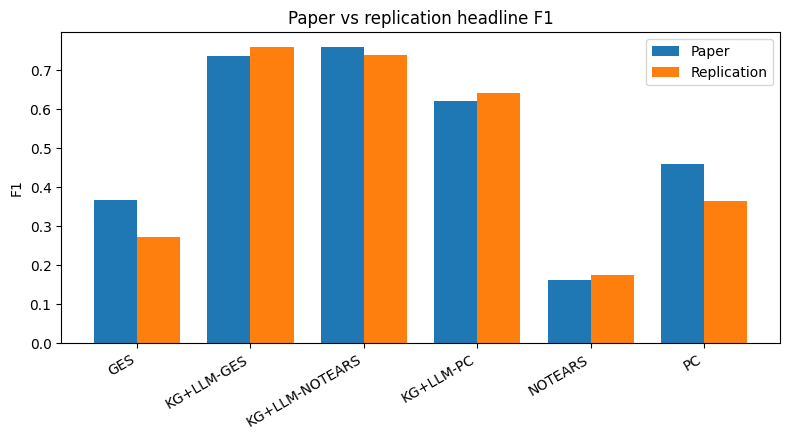

In [13]:
plt.figure(figsize=(8, 4.5))
x = np.arange(len(headline))
width = 0.38
plt.bar(x - width/2, headline["paper_f1"], width=width, label="Paper")
plt.bar(x + width/2, headline["f1"], width=width, label="Replication")
plt.xticks(x, headline["method"], rotation=30, ha="right")
plt.ylabel("F1")
plt.title("Paper vs replication headline F1")
plt.legend()
plt.tight_layout()
plt.show()

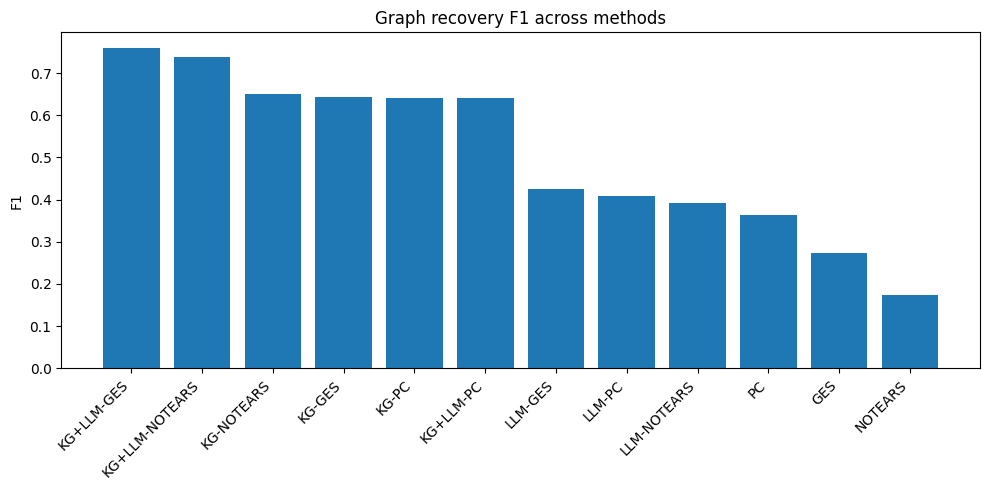

,method,precision,recall,f1,tp,fp,fn,shd
0,KG+LLM-GES,0.758621,0.758621,0.758621,22,7,7,14
1,KG+LLM-NOTEARS,1.000000,0.586207,0.739130,17,0,12,12
2,KG-NOTEARS,1.000000,0.482759,0.651163,14,0,15,15
3,KG-GES,0.666667,0.620690,0.642857,18,9,11,20
4,KG-PC,0.708333,0.586207,0.641509,17,7,12,19
5,KG+LLM-PC,0.708333,0.586207,0.641509,17,7,12,19
6,LLM-GES,0.555556,0.344828,0.425532,10,8,19,27
7,LLM-PC,0.600000,0.310345,0.409091,9,6,20,26
8,LLM-NOTEARS,0.529412,0.310345,0.391304,9,8,20,28
9,PC,0.533333,0.275862,0.363636,8,7,21,28


In [14]:
plot_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
plt.figure(figsize=(10, 5))
plt.bar(plot_df["method"], plot_df["f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1")
plt.title("Graph recovery F1 across methods")
plt.tight_layout()
plt.show()

plot_df[["method", "precision", "recall", "f1", "tp", "fp", "fn", "shd"]]

In [15]:
print("data shape:", ds.data.shape)
print("truth edges:", ds.truth_graph.number_of_edges())
print("KG priors:", len(ds.kg_priors))
print("LLM priors:", len(ds.llm_priors))
ds.data.head()

data shape: (500, 18)
truth edges: 29
KG priors: 42
LLM priors: 9


,Market_Return,Interest_Rate,Regulatory_Risk,Inflation,Competition_Intensity,Governance_Score,ESG_Score,Innovation_Index,Revenue_Growth,Cost_Efficiency,EBITDA_Margin,Leverage,Liquidity,Credit_Risk,Valuation_Multiple,Earnings_Surprise,Sentiment,Monthly_Return
0,-0.128218,1.604288,-0.723077,0.931457,0.491921,0.168564,0.109298,0.401202,0.641065,0.477221,0.741932,-0.189857,0.057104,-0.259885,0.490840,0.631170,0.259582,0.477261
1,1.349593,-0.137742,-1.820534,0.364371,-1.067440,0.867895,0.757050,0.687639,0.773854,1.050786,0.927082,-1.697285,1.052083,-1.304925,1.375283,1.441596,1.316907,0.940680
2,-0.205279,-0.058275,1.391290,-1.034284,-0.722092,0.137378,0.043400,-0.247957,0.025986,0.115184,0.116728,-0.701657,0.545656,-0.379830,0.143301,0.057124,0.613851,0.367611
3,-0.278276,0.454684,3.598963,0.088651,-0.094933,-1.154700,-0.985458,1.760461,1.852168,-0.249413,1.034153,1.672674,-1.262267,1.461809,0.014346,1.580361,-0.777184,-0.477428
4,1.865459,0.062528,-0.411952,-1.439804,1.717554,-0.526107,-0.513701,0.325916,0.537302,-0.500203,-0.408875,0.808643,-0.470094,0.673110,-0.349844,-0.453263,-0.626705,-0.330392


In [16]:
truth_edges_df = pd.DataFrame(sorted(ds.truth_graph.edges()), columns=["source", "target"])
truth_edges_df.head(15)

,source,target
0,Competition_Intensity,EBITDA_Margin
1,Competition_Intensity,Revenue_Growth
2,Cost_Efficiency,EBITDA_Margin
3,Cost_Efficiency,Monthly_Return
4,Credit_Risk,Monthly_Return
5,Credit_Risk,Valuation_Multiple
6,EBITDA_Margin,Monthly_Return
7,EBITDA_Margin,Valuation_Multiple
8,ESG_Score,Sentiment
9,ESG_Score,Valuation_Multiple
